# Atividade Prática | Natural Language Processing
## Criação de modelo supervisionado para análise de fake news

**Objetivo:**  Criar um modelo de classificação de notícias como verdadeiras ou falsas usando o corpus FakeBr.

**Pontos de atenção:**
- A acurácia do modelo gerado deve ser de pelo menos 85%;
- É necessário realizar o balanceamento do corpus. A base de dados apresenta mais palavras relacionadas aos textos verdadeiros do que aos falsos;
- Divisão treino/teste: 75% para treino (dividido igualmente entre real e fake) e 25% teste.

### 1. Import de bibliotecas e funções auxiliares

### 1.1. Bibliotecas

In [1]:
import os
import random
import pandas as pd
import numpy as np

import unidecode
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from wordcloud import WordCloud

import matplotlib.pyplot as plt
from PIL import Image

### 1.2. Funções

In [2]:
stop_words = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

def preprocess_text(texto, ru= '4700355'):
    
    # Lowercase
    texto = texto.lower()

    # Remove acentos
    texto = unidecode.unidecode(texto) 
    
    # Remove números e pontuação
    texto = re.sub(r'[^a-zà-ú\s]', '', texto)
    
    # Tokenização
    tokens = word_tokenize(texto)
    
    # Remover stopwords + stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

In [3]:
def gerar_nuvem_palavras(arquivo_mascara="cloud_mask.png",
                         dicionario_tokens_e_frequencia={'exemplo':1,
                                     'exemplo bigramas':2,
                                     'exemplo de trigrama':1,
                                     'ALTERAR':3},
                        ru = None,
                        color= '#2E7D32'):
    """
    Gera uma nuvem de palavras com base em seu dicionário de palavras ou ngramas
    como a chave e a frequência de aparição do token como valor (inteiro).

    Parâmetros:
        dicionario_tokens_e_frequencia (dict): O dicionário de tokens e suas 
                                               respectivas frequências de 
                                               aparição nos textos.
        arquivo_mascara (str): O nome do arquivo da imagem de máscara. Pde ser:
                                            cloud_mask.png
                                            mapa_brasil_mask.png
                                            thumbs_up_mask.png        
                                            thumbs_down_mask.png
                                            <Outro arquivo de sua escolha>

    Exemplos de Uso:
        1. Para gerar uma nuvem de palavras na máscara mapa do brasil:
            gerar_nuvem_palavras(dicionario_tokens_e_frequencia=word_dict,
                                 arquivo_mascara='mapa_brasil_mask.png')
    """

    # Seletor de função de cor
    def color_function(mask):
        if mask == "mapa_brasil_mask.png":
            def color_func(word, font_size, position, orientation, random_state=None,**kwargs):
                return "hsl(190, 40%%, %d%%)" % random.randint(30, 60) #sky
            color_cont = (219, 236, 240)
        elif mask == "thumbs_down_mask.png":
            def color_func(word, font_size, position, orientation, random_state=None,**kwargs):
                return "hsl(0, 80%%, %d%%)" % random.randint(30, 60) #fake
            color_cont = (250, 209, 209)
        elif mask == "thumbs_up_mask.png":
            def color_func(word, font_size, position, orientation, random_state=None,**kwargs):
                return "hsl(130, 40%%, %d%%)" % random.randint(30, 60) #real
            color_cont = (219, 240, 223)
        else:
            def color_func(word, font_size, position, orientation, random_state=None,**kwargs):
                return "hsl(0, 0%%, %d%%)" % random.randint(60, 100) #grey
            color_cont = (219, 236, 240)
        return color_func, color_cont

    color_function, color_cont = color_function(arquivo_mascara)

    imagem_mascara = np.array(Image.open(os.path.join("data/img/", arquivo_mascara)))

    print(f"   * Um total de {len(dicionario_tokens_e_frequencia)} tokens foram "+
        "computadas a partir do conjunto de dados.\n")
    nuvem_palavras = WordCloud(
                            width=1080,
                            height=1080,
                            max_font_size=110,
                            background_color="white",
                            collocations=False,
                            mask=imagem_mascara,
                            contour_width=3,
                            contour_color = color_cont
                            ).generate_from_frequencies(dicionario_tokens_e_frequencia)
    nuvem_palavras.recolor(color_func=color_function, random_state=3)

    fig, ax = plt.subplots(figsize=(12, 10))

    plt.subplots_adjust(left=0.25)

    ax.imshow(nuvem_palavras, interpolation='bilinear')
    ax.axis('off')
    
    if ru:
        fig.text(
            0.2, 0.5,
            f"RU: {ru}",
            fontsize=18,
            rotation=90,
            va='center',
            ha='center',
            fontweight='bold',
            color= color
        )
    
    plt.show()

    return nuvem_palavras, len(dicionario_tokens_e_frequencia)

## 2. Carregando base de dados

In [4]:
df = pd.read_csv('data/pre-processed.csv', usecols = ['label', 'preprocessed_news'])
df.head()

,label,preprocessed_news
0,fake,katia abreu diz vai colocar expulsao moldura n...
1,fake,ray peita bolsonaro conservador fake entrevist...
2,fake,reinaldo azevedo desmascarado policia federal ...
3,fake,relatorio assustador bndes mostra dinheiro pub...
4,fake,radialista americano fala sobre pt vendem ilus...


In [5]:
# Cria coluna com contagem de palavras
df['words_count'] = df['preprocessed_news'].str.split().str.len()
df.head()

,label,preprocessed_news,words_count
0,fake,katia abreu diz vai colocar expulsao moldura n...,99
1,fake,ray peita bolsonaro conservador fake entrevist...,143
2,fake,reinaldo azevedo desmascarado policia federal ...,153
3,fake,relatorio assustador bndes mostra dinheiro pub...,339
4,fake,radialista americano fala sobre pt vendem ilus...,66


In [6]:
# Quantifica noticias por label
df['label'].value_counts()

label
fake    3600
true    3600
Name: count, dtype: int64

In [7]:
# Quantifica palavras por label
df.groupby('label')['words_count'].sum()

label
fake     388587
true    2249768
Name: words_count, dtype: int64

In [8]:
# Calcula métricas de tendência central e distribuição para contagem de palavras por categoria
df.groupby('label')['words_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3600.0,107.940833,72.152004,5.0,67.75,92.0,130.0,1220.0
true,3600.0,624.935556,385.432837,13.0,364.00,523.0,806.0,4229.0


## 3. Pré-processamento
1. Lowercase;
2. Remover acentos;
3. Remover pontuação;
4. Tokenização;
5. Remover stopwords;
6. Stemming (reduzir palavras);
7. Truncamento

In [9]:
df['processed_text'] = df['preprocessed_news'].apply(preprocess_text)

In [10]:
# Cria coluna com contagem de tokens
df['tokens_count'] = df['processed_text'].str.split().str.len()

In [11]:
MAX_LEN = 350

# Cria coluna com texto truncado que será utilizada no modelo
df['truncated_text'] = (
    df['processed_text']
    .str.split()                    # string → lista de palavras
    .str[:MAX_LEN]                  # truncamento
    .str.join(' ')                  # lista → string novamente
)

# Cria coluna com contagem de palavras
df['truncated_count'] = df['truncated_text'].str.split().str.len()

In [12]:
df.head()

,label,preprocessed_news,words_count,processed_text,tokens_count,truncated_text,truncated_count
0,fake,katia abreu diz vai colocar expulsao moldura n...,99,kat abr diz vai coloc expulsa mold nao reclam ...,99,kat abr diz vai coloc expulsa mold nao reclam ...,99
1,fake,ray peita bolsonaro conservador fake entrevist...,143,ray peit bolsonar conserv fak entrev danil gen...,142,ray peit bolsonar conserv fak entrev danil gen...,142
2,fake,reinaldo azevedo desmascarado policia federal ...,153,reinald azeved desmascar polic feder ferrenh c...,153,reinald azeved desmascar polic feder ferrenh c...,153
3,fake,relatorio assustador bndes mostra dinheiro pub...,339,relatori assust bnd mostr dinh publ brasil jor...,337,relatori assust bnd mostr dinh publ brasil jor...,337
4,fake,radialista americano fala sobre pt vendem ilus...,66,radial americ fal sobr pt vend ilusa pov brasi...,66,radial americ fal sobr pt vend ilusa pov brasi...,66


In [13]:
df.groupby('label')['truncated_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3600.0,105.610833,59.319503,5.0,67.0,92.0,129.0,350.0
true,3600.0,327.620000,53.657223,13.0,350.0,350.0,350.0,350.0


In [14]:
# Converte coluna de label em 0/1
df.insert(1, 'label_bin', df['label'].map({'fake': 0, 'true': 1}))

## 4. Divisão Treino e Teste

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df['truncated_text'],
    df['label_bin'],
    test_size=0.25,
    random_state=42,
    stratify=df['label_bin']
)

## 5. Vetorização (TF-IDF)

In [16]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## 6. Treinando o modelo - Naive Bayes

In [17]:
model = LogisticRegression(solver = 'lbfgs')
model.fit(X_train_tfidf, y_train)

LogisticRegression()

## 7. Avaliação

In [18]:
y_pred = model.predict(X_test_tfidf)

print('A acurácia obtida pelo modelo é de: ', round(accuracy_score(y_test, y_pred), 2))

A acurácia obtida pelo modelo é de:  0.95


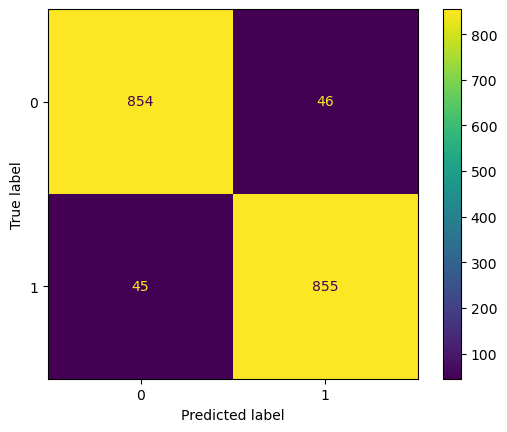

In [19]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

### 8. Nuvem de palavras

In [20]:
# Recuperando unigramas e bigramas utilizados no TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Cria dataframe com conteúdo de noticias separados por categoria
X_train_fake = X_train[y_train == 0]
X_train_true = X_train[y_train == 1]

# Aplica o vetorizador nos dataframes separados por classe
X_fake_tfidf = vectorizer.transform(X_train_fake)
X_true_tfidf = vectorizer.transform(X_train_true)

# Somar ocorrências (frequência aproximada via TF-IDF)
fake_scores = np.asarray(X_fake_tfidf.sum(axis=0)).flatten()
true_scores = np.asarray(X_true_tfidf.sum(axis=0)).flatten()

# Criar DataFrame comparativo
df_terms = pd.DataFrame({
    'term': feature_names,
    'fake_score': fake_scores,
    'true_score': true_scores
})

# Cria coluna com o tamanho do termo (palavra ou bigrama)
df_terms['count_terms'] = df_terms['term'].str.split().str.len()

print('Dimensão do dataframe de termos (palavra e bigramas) utilizados no modelo: ', df_terms.shape)
df_terms.head()

Dimensão do dataframe de termos (palavra e bigramas) utilizados no modelo:  (5000, 4)


,term,fake_score,true_score,count_terms
0,abaix,18.962073,15.436288,1
1,abaix integr,0.628139,4.789770,2
2,abal,2.719454,2.500773,1
3,abandon,6.082892,5.489875,1
4,abastec,2.665944,4.721101,1


In [21]:
# Cálculo de termos utilizados
cols = ['fake_score', 'true_score']

for col in cols:
    df_filtrado = df_terms[df_terms[col] != 0]
    print(f'Quantidade de termos utilizados para coluna {col}: {df_filtrado.shape[0]}')
    display(pd.DataFrame(df_filtrado['count_terms'].value_counts()))
    print('-' * 60)

Quantidade de termos utilizados para coluna fake_score: 4953


,count
count_terms,
1,3541
2,1412


------------------------------------------------------------
Quantidade de termos utilizados para coluna true_score: 4997


,count
count_terms,
1,3556
2,1441


------------------------------------------------------------


In [22]:
# Cria dicionário com termos e ocorrências
fake_dict = (
    df_terms
    .sort_values('fake_score', ascending=False)
    .head(1000)
    .set_index('term')['fake_score']
    .to_dict()
)

true_dict = (
    df_terms
    .sort_values('true_score', ascending=False)
    .head(1000)
    .set_index('term')['fake_score']
    .to_dict()
)

   * Um total de 1000 tokens foram computadas a partir do conjunto de dados.



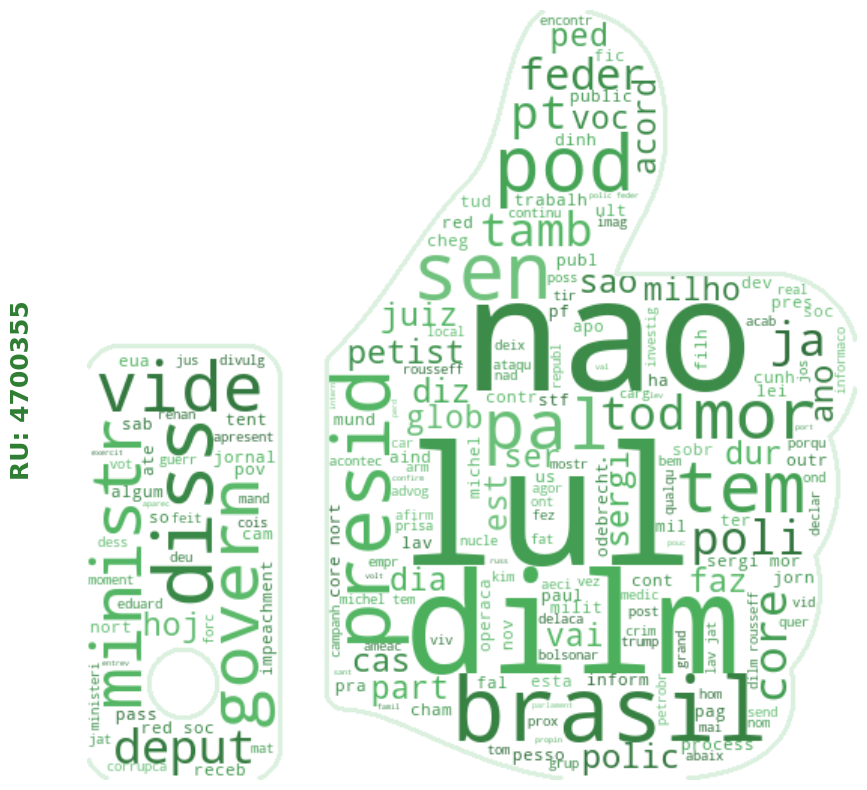

In [23]:
# Noticias verdadeiras
gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=true_dict,
    arquivo_mascara='thumbs_up_mask.png',
    ru = '4700355'
);

   * Um total de 1000 tokens foram computadas a partir do conjunto de dados.



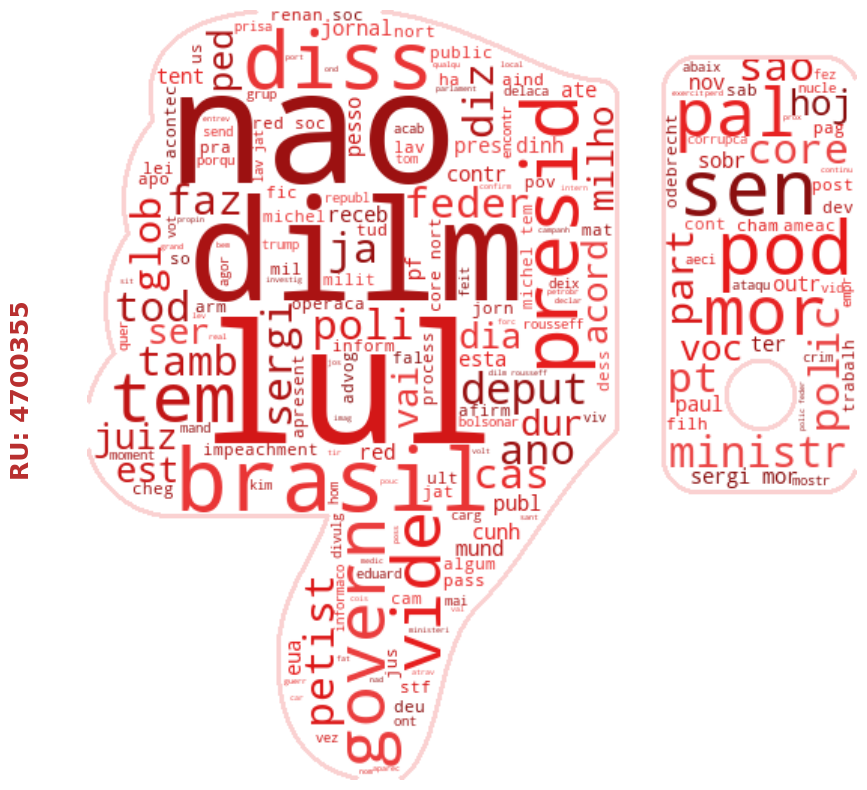

In [24]:
# Fake News
gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=fake_dict,
    arquivo_mascara='thumbs_down_mask.png',
    ru = '4700355',
    color = '#B82E2E'
);